# Importing packages

In [3]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, binary_fill_holes, distance_transform_edt
from skimage import measure, morphology
from skimage.filters import threshold_otsu
from shapely.geometry import Polygon
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import yaml
from pathlib import Path
from matplotlib import colormaps
import seaborn as sns
from scipy.ndimage import gaussian_filter, binary_fill_holes, distance_transform_edt
from skimage import measure, morphology
from skimage.filters import threshold_otsu
from shapely.geometry import Point
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

In [4]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])
metadata_dir = Path(config['metadata_dir'])

In [5]:
adata = ad.read_h5ad(results_dir / "adata.h5ad")

In [7]:
extra_patient_info = pd.read_excel(metadata_dir / 'extra_patients_info.xlsx', sheet_name='Detailed info')
#rename columns to match adata.obs
extra_patient_info.rename(columns={
    "Patient ID": "patient_ID"}, inplace=True)
#get the survival time in months and event
extra_patient_info["survival_time_months"] = extra_patient_info["Survival after NMC diagnosis"].str.split(" month").str[0].astype(float)
adata.obs = adata.obs.merge(extra_patient_info, how='left', left_on='patient_ID', right_on='patient_ID')
adata.obs["patient_exp"] = adata.obs["patient_ID"].astype(str) + "_ROI" + adata.obs["rois"].astype(str)


In [11]:
def extract_all_tumor_cores_otsu(adata, image_size=256, sigma=2, min_size=50, resolution_um_per_px=0.17, plot=True):
    # Select tumor cells
    df = adata.obs[adata.obs['cell_type'] == 'Tumor_cells']
    x_coords = np.round(df['Cell Center X'].values)
    y_coords = np.round(df['Cell Center Y'].values)
    
    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    # Scale tumor cell coords to image pixels
    scale_x = (x_coords - x_min) / (x_max - x_min) * (image_size - 1)
    scale_y = (y_coords - y_min) / (y_max - y_min) * (image_size - 1)

    # Rasterize tumor cells into binary image
    image = np.zeros((image_size, image_size), dtype=np.uint8)
    for x_pix, y_pix in zip(scale_x.astype(int), scale_y.astype(int)):
        image[y_pix, x_pix] = 255

    # Gaussian blur and threshold
    blurred_image = gaussian_filter(image, sigma=sigma)
    blurred_image = blurred_image * (blurred_image > np.percentile(blurred_image, 10))
    otsu_thresh = threshold_otsu(blurred_image)
    binary_mask = blurred_image > otsu_thresh
    
    # Clean small objects
    cleaned_mask = morphology.remove_small_objects(binary_mask, min_size=min_size)

    # Pad mask to prevent edge artifacts in contour finding
    padded_mask = np.pad(cleaned_mask, pad_width=1, mode='constant', constant_values=0)

    # Find contours on padded mask
    contours = measure.find_contours(padded_mask.astype(float), 0.5)
    if len(contours) == 0:
        print("No contour found.")
        return None, None

    polygons = []
    for contour in contours:
        # Adjust coordinates due to padding (-1 pixel)
        contour_x = (contour[:, 1] - 1) / (image_size - 1) * (x_max - x_min) + x_min
        contour_y = (contour[:, 0] - 1) / (image_size - 1) * (y_max - y_min) + y_min
        poly = Polygon(zip(contour_x, contour_y))
        polygons.append(poly)

    n_cores = len(polygons)

     # Compute diffusion metric (using first polygon)
    diffusion_metrics = []
    for poly in polygons:
        perimeter = poly.length
        area = poly.area
        if area > 0:
            curl = (perimeter**2) / (4 * np.pi * area)
        else:
            curl = np.nan  # handle degenerate case
        diffusion_metrics.append(curl)

    median_diffusion_score = np.nanmedian(diffusion_metrics)



    # --- Compute distance map from tumor cores ---
    # Distance transform needs tumor core pixels True inside, False outside
    # Use filled mask without padding here for distance transform
    inverse_mask = ~cleaned_mask  # True outside tumor cores
    distance_map = distance_transform_edt(inverse_mask)  # distances in pixel units

    # Calculate distance for every cell in adata.obs
    all_x = np.round(adata.obs['Cell Center X'].values)
    all_y = np.round(adata.obs['Cell Center Y'].values)

    # Scale all cell coords to pixel indices
    scale_all_x = (all_x - x_min) / (x_max - x_min) * (image_size - 1)
    scale_all_y = (all_y - y_min) / (y_max - y_min) * (image_size - 1)

    pix_x = np.clip(scale_all_x.astype(int), 0, image_size - 1)
    pix_y = np.clip(scale_all_y.astype(int), 0, image_size - 1)

    # Lookup distance for each cell
    cell_distances_pixels = distance_map[pix_y, pix_x]

    # Convert pixel distances back to original coordinate units
    pixel_size_x = (x_max - x_min) / (image_size - 1)
    pixel_size_y = (y_max - y_min) / (image_size - 1)
    # Use average pixel size for approximate Euclidean distance scaling
    avg_pixel_size = (pixel_size_x + pixel_size_y) / 2
    cell_distances = cell_distances_pixels * avg_pixel_size
    cell_distances_um = cell_distances * resolution_um_per_px  # distances in microns

    if plot:
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))

        axs[0].imshow(image, cmap='gray')
        axs[0].set_title('Tumor Cells')

        axs[1].imshow(blurred_image, cmap='gray')
        axs[1].axhline(otsu_thresh, color='r', linestyle='--')
        axs[1].set_title(f'Gaussian Blurred + Otsu Threshold')

        axs[2].imshow(cleaned_mask, cmap='gray')
        axs[2].set_title('Filled Mask after threshold + clean')

        axs[3].imshow(image, cmap='gray')
        for poly in polygons:
            x_img = (np.array(poly.exterior.xy[0]) - x_min) / (x_max - x_min) * (image_size - 1)
            y_img = (np.array(poly.exterior.xy[1]) - y_min) / (y_max - y_min) * (image_size - 1)
            axs[3].plot(x_img, y_img, color='red')
        axs[3].set_title('All Tumor Core Contours')
        
        plt.show()

    return polygons, cell_distances_um, n_cores, median_diffusion_score

In [12]:
def cell_type_proportions_in_tumor_cores(adata, polygons):
    x_coords = adata.obs['Cell Center X'].values
    y_coords = adata.obs['Cell Center Y'].values
    cell_types = adata.obs['cell_type'].values

    inside_core = []
    for x, y in zip(x_coords, y_coords):
        point = Point(x, y)
        inside = any(poly.contains(point) for poly in polygons)
        inside_core.append(inside)
    
    # Create a dataframe for easy aggregation
    df = pd.DataFrame({
        'cell_type': cell_types,
        'inside_core': inside_core
    })

    # Total number of cells inside tumor core
    total_inside = df['inside_core'].sum()

    # Compute counts per cell type inside cores
    counts = df[df['inside_core']].groupby('cell_type').size()

    # Calculate proportions
    proportions = counts / total_inside

    print("Cell type proportions inside tumor core:")
    print(proportions)

    return proportions

Processing experiment: Run141_ROI11


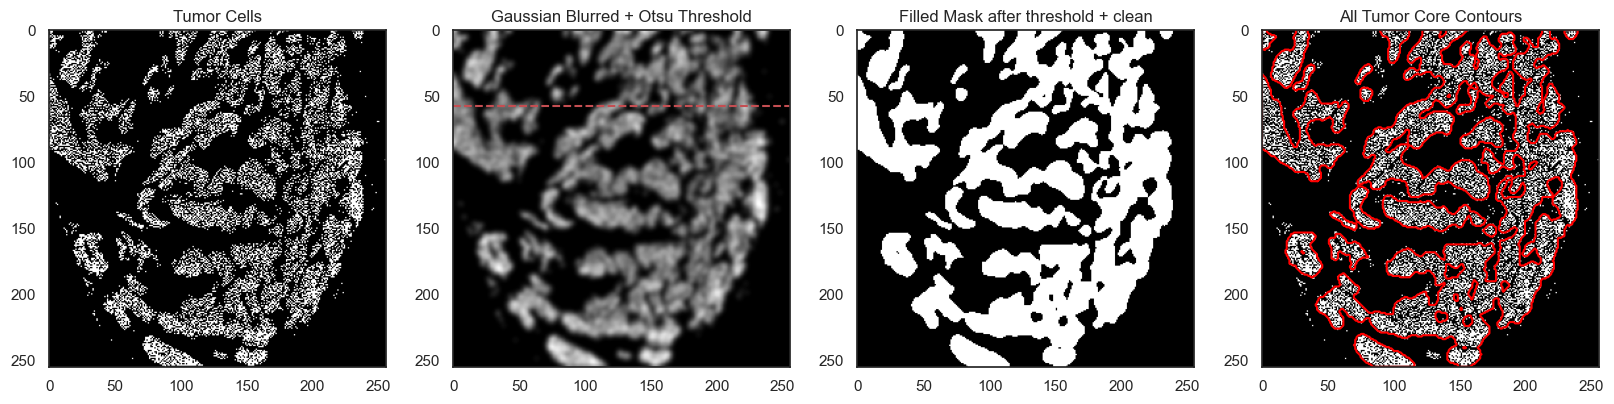

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.024019
B_cells                        0.001865
CD4+_T_cells                   0.001119
CD8+_T_cells                   0.000448
DCs                            0.000746
Endothelial_cells              0.003431
Granulocytes                   0.000746
Lymphatic_endothelial_cells    0.002163
M1_M2_macrophages              0.004625
M1_macrophages                 0.004849
M2_macrophages                 0.001716
MDSCs                          0.003133
Mast_cells                     0.001716
NFC                            0.009772
Plasma_cells                   0.000895
Treg_T_cells                   0.000522
Tumor_cells                    0.938237
dtype: float64
Processing experiment: Run141_ROI16


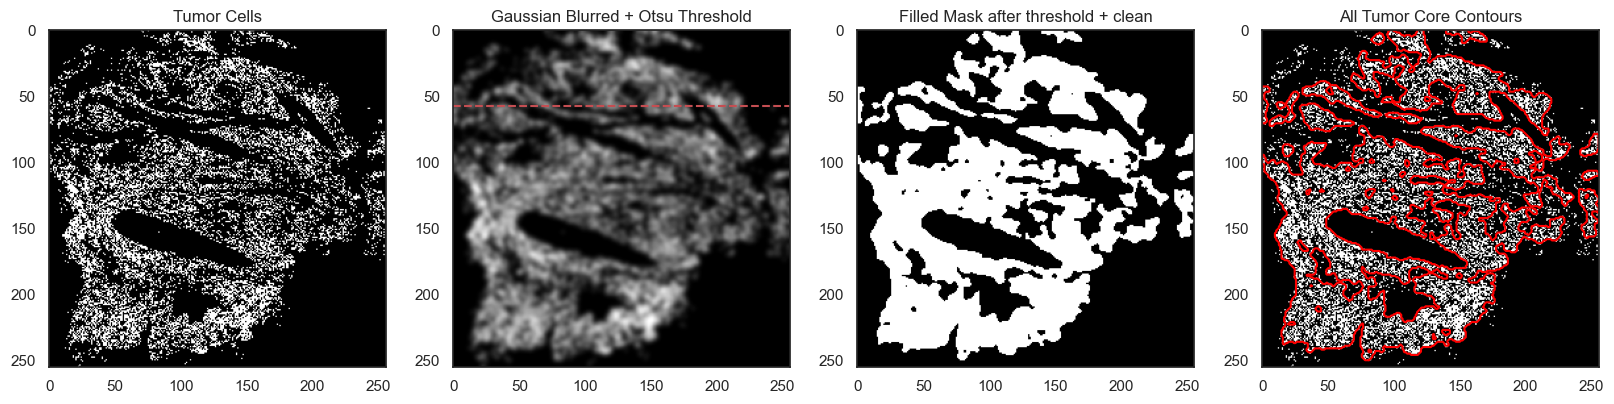

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.015636
B_cells                        0.000711
CD4+_T_cells                   0.009240
CD8+_T_cells                   0.006041
Endothelial_cells              0.024368
Epithelial_cells               0.017768
Granulocytes                   0.034724
Lymphatic_endothelial_cells    0.008478
M1_M2_macrophages              0.008072
M1_macrophages                 0.008529
M2_macrophages                 0.001472
Mast_cells                     0.013199
NFC                            0.178292
NK_cells                       0.001929
Plasma_cells                   0.001066
Treg_T_cells                   0.002894
Tumor_cells                    0.667580
dtype: float64
Processing experiment: Run141_ROI7


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



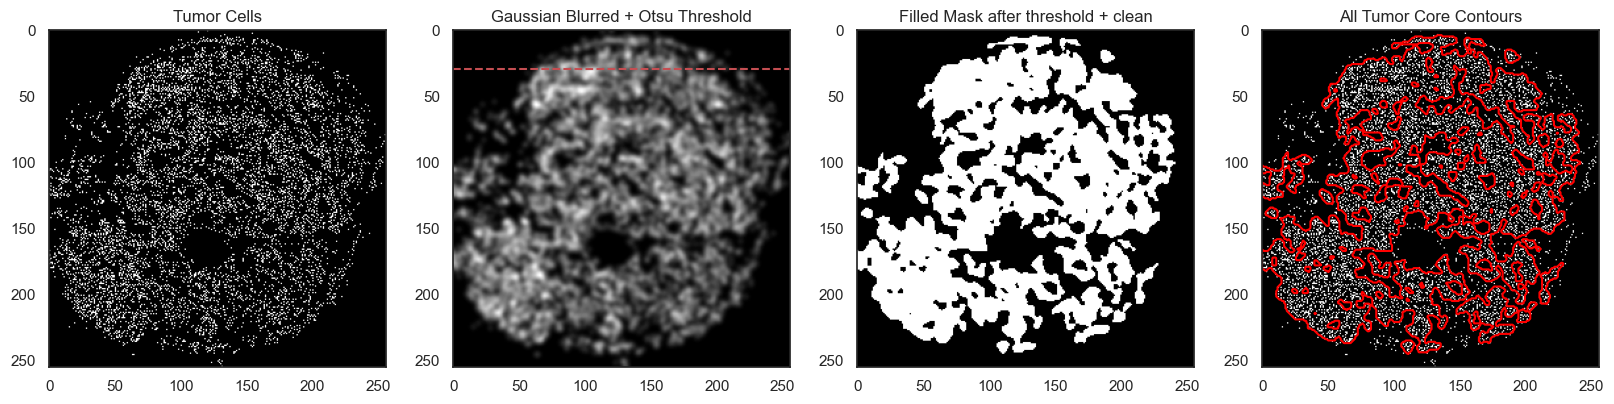

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.029466
B_cells                        0.003556
CD4+_T_cells                   0.008332
CD8+_T_cells                   0.009551
Endothelial_cells              0.019407
Epithelial_cells               0.004166
Granulocytes                   0.022963
Lymphatic_endothelial_cells    0.003150
M1_M2_macrophages              0.005283
M1_macrophages                 0.005690
M2_macrophages                 0.004267
Mast_cells                     0.008840
NFC                            0.215607
NK_cells                       0.001118
Plasma_cells                   0.003658
Treg_T_cells                   0.001524
Tumor_cells                    0.653424
dtype: float64
Processing experiment: Run145_ROI3


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



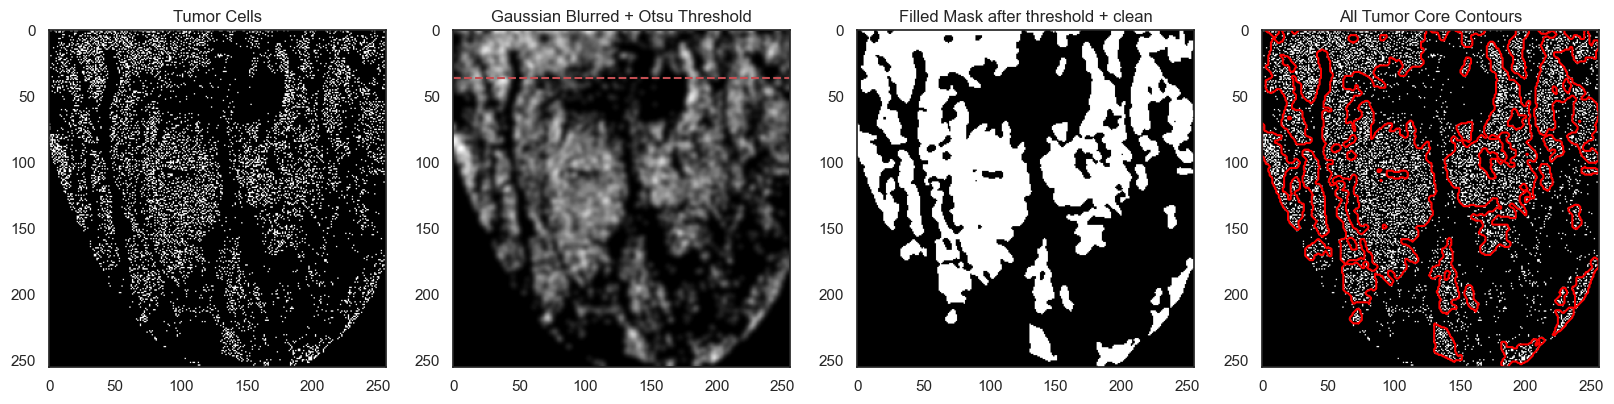

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.016919
B_cells                        0.001224
CD4+_T_cells                   0.002894
CD8+_T_cells                   0.003785
DCs                            0.000445
Endothelial_cells              0.002671
Granulocytes                   0.000000
Lymphatic_endothelial_cells    0.003005
M1_M2_macrophages              0.023264
M1_macrophages                 0.012801
M2_macrophages                 0.024154
MDSCs                          0.014915
Mast_cells                     0.000334
NFC                            0.133682
NK_cells                       0.002226
Plasma_cells                   0.000111
Treg_T_cells                   0.002894
Tumor_cells                    0.754675
dtype: float64
Processing experiment: Run141_ROI19


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



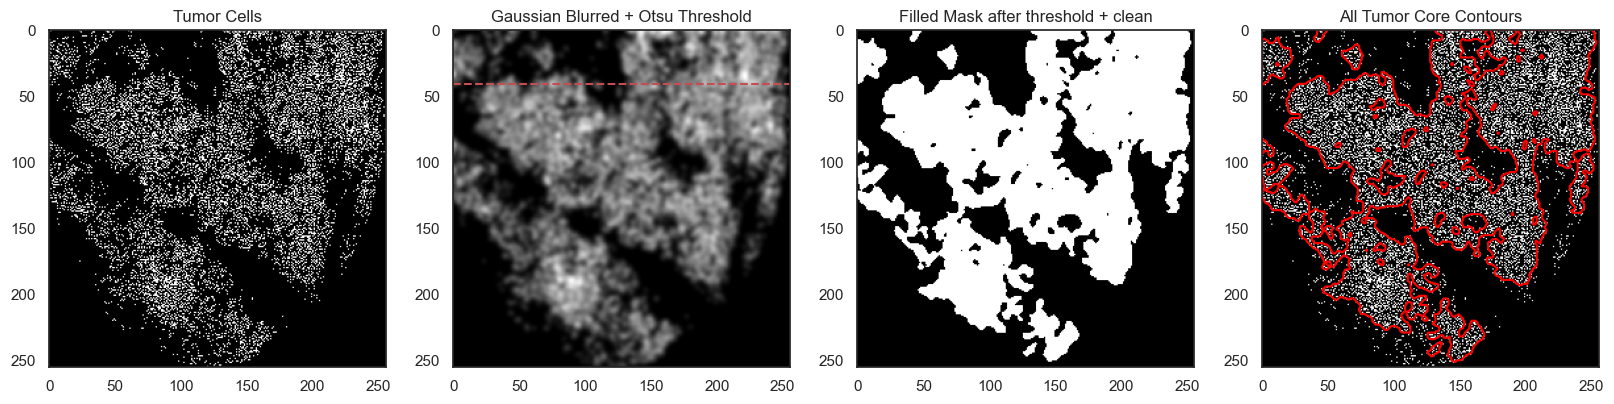

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.046496
B_cells                        0.000000
CD4+_T_cells                   0.012143
CD8+_T_cells                   0.014218
DCs                            0.001691
Endothelial_cells              0.003074
Granulocytes                   0.008838
Lymphatic_endothelial_cells    0.002459
M1_M2_macrophages              0.008992
M1_macrophages                 0.014218
M2_macrophages                 0.006379
MDSCs                          0.091223
Mast_cells                     0.000461
NFC                            0.047187
NK_cells                       0.000000
Plasma_cells                   0.000077
Treg_T_cells                   0.001691
Tumor_cells                    0.740855
dtype: float64
Processing experiment: Run141_ROI1


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



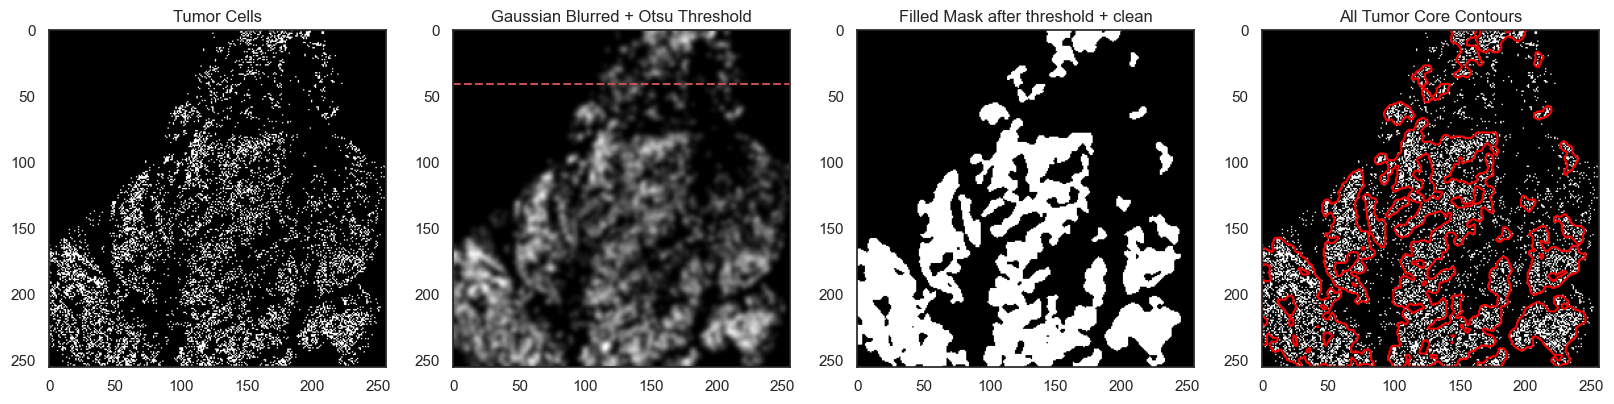

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.086372
B_cells                        0.000088
CD4+_T_cells                   0.005133
CD8+_T_cells                   0.006460
DCs                            0.000531
Endothelial_cells              0.077876
Epithelial_cells               0.001681
Granulocytes                   0.030619
Lymphatic_endothelial_cells    0.032478
M1_M2_macrophages              0.006726
M1_macrophages                 0.004425
M2_macrophages                 0.013009
MDSCs                          0.009381
Mast_cells                     0.003274
NFC                            0.124602
NK_cells                       0.000708
Treg_T_cells                   0.001239
Tumor_cells                    0.595398
dtype: float64
Processing experiment: Run141_ROI8


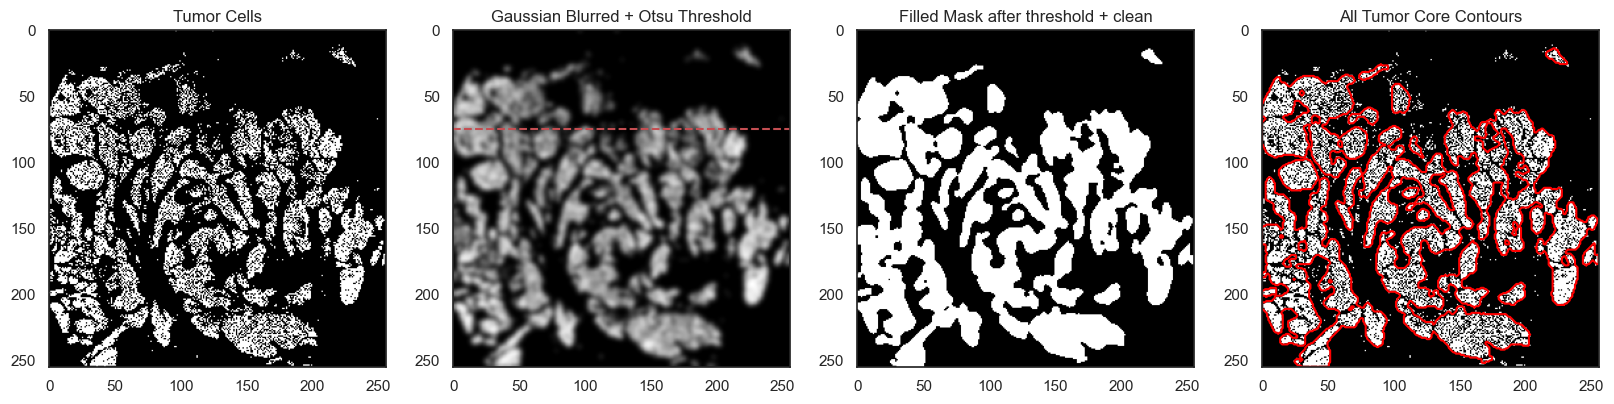

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.039514
B_cells                        0.000000
CD4+_T_cells                   0.002439
CD8+_T_cells                   0.000846
DCs                            0.001145
Endothelial_cells              0.008062
Granulocytes                   0.001095
Lymphatic_endothelial_cells    0.003036
M1_M2_macrophages              0.001393
M1_macrophages                 0.005574
M2_macrophages                 0.003434
MDSCs                          0.002239
Mast_cells                     0.001443
NFC                            0.017120
NK_cells                       0.000050
Plasma_cells                   0.000398
Treg_T_cells                   0.003882
Tumor_cells                    0.908331
dtype: float64
Processing experiment: Run141_ROI17


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



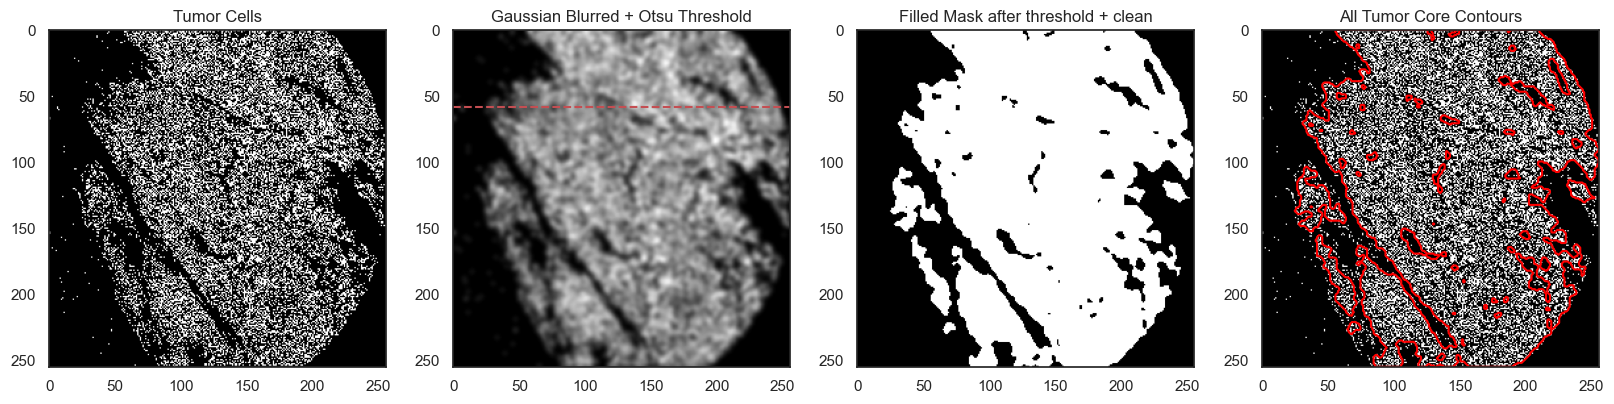

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.054909
B_cells                        0.004968
CD4+_T_cells                   0.009849
CD8+_T_cells                   0.010285
DCs                            0.000392
Endothelial_cells              0.010023
Granulocytes                   0.051466
Lymphatic_endothelial_cells    0.003312
M1_M2_macrophages              0.001917
M1_macrophages                 0.006580
M2_macrophages                 0.031595
Mast_cells                     0.000654
NFC                            0.001351
NK_cells                       0.000305
Plasma_cells                   0.002179
Treg_T_cells                   0.000567
Tumor_cells                    0.809648
dtype: float64
Processing experiment: Run145_ROI10


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



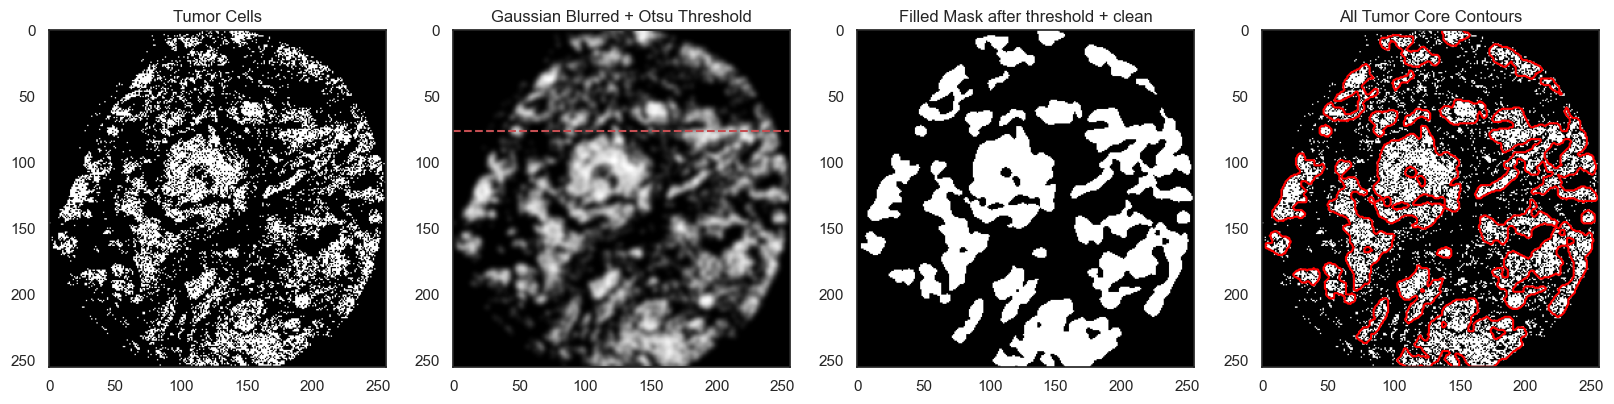

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.034342
B_cells                        0.002060
CD4+_T_cells                   0.003018
CD8+_T_cells                   0.005556
DCs                            0.004119
Endothelial_cells              0.033337
Epithelial_cells               0.032570
Granulocytes                   0.020500
Lymphatic_endothelial_cells    0.003688
M1_M2_macrophages              0.001868
M1_macrophages                 0.002347
M2_macrophages                 0.011639
MDSCs                          0.019829
Mast_cells                     0.001676
NFC                            0.168024
NK_cells                       0.000575
Plasma_cells                   0.000144
Treg_T_cells                   0.000575
Tumor_cells                    0.654134
dtype: float64
Processing experiment: Run145_ROI11


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



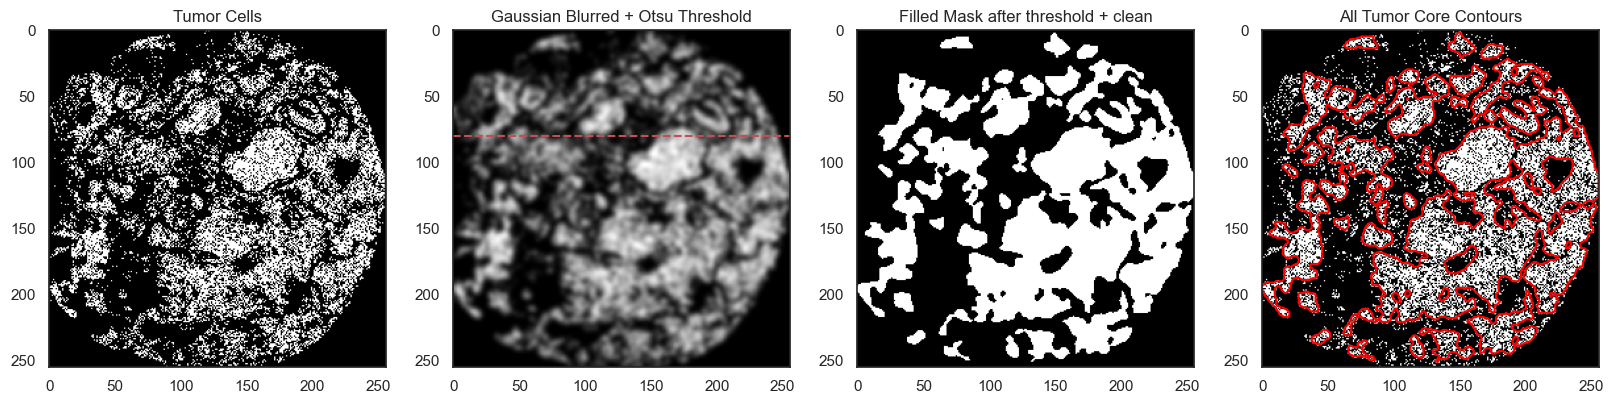

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.034465
B_cells                        0.000512
CD4+_T_cells                   0.001891
CD8+_T_cells                   0.007011
DCs                            0.000394
Endothelial_cells              0.031117
Epithelial_cells               0.028478
Granulocytes                   0.010635
Lymphatic_endothelial_cells    0.000551
M1_M2_macrophages              0.001457
M1_macrophages                 0.000394
M2_macrophages                 0.015086
MDSCs                          0.011974
Mast_cells                     0.002363
NFC                            0.162518
NK_cells                       0.000906
Treg_T_cells                   0.000276
Tumor_cells                    0.689972
dtype: float64
Processing experiment: Run141_ROI15


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



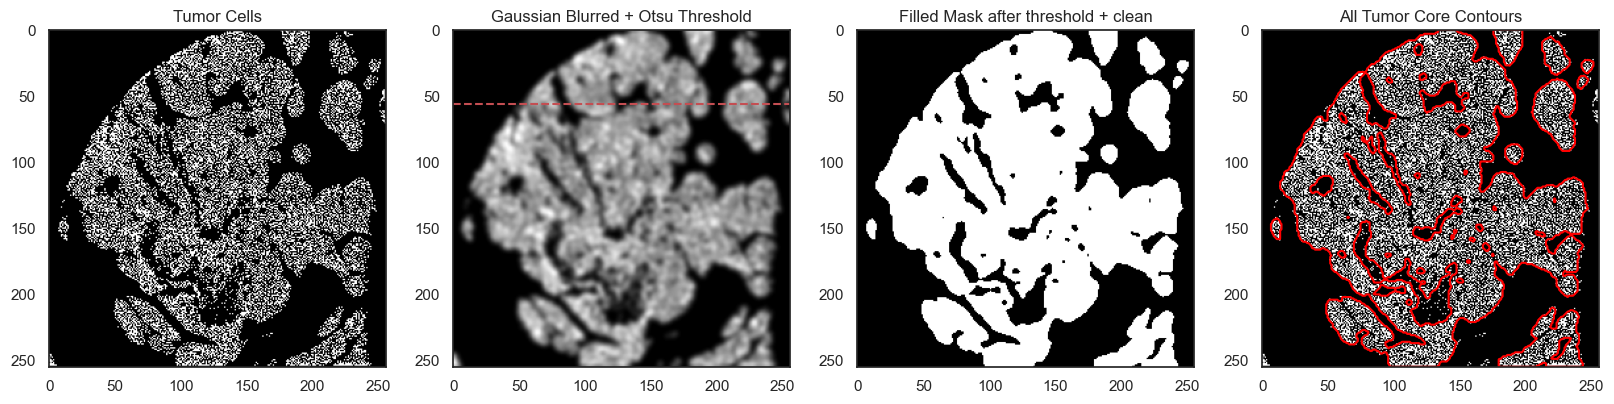

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.024683
B_cells                        0.012226
CD4+_T_cells                   0.000058
CD8+_T_cells                   0.000634
DCs                            0.000865
Endothelial_cells              0.004152
Granulocytes                   0.000115
Lymphatic_endothelial_cells    0.003691
M1_M2_macrophages              0.000461
M1_macrophages                 0.001038
M2_macrophages                 0.026990
MDSCs                          0.003114
Mast_cells                     0.000000
NFC                            0.009170
NK_cells                       0.000115
Plasma_cells                   0.000288
Treg_T_cells                   0.000807
Tumor_cells                    0.911592
dtype: float64
Processing experiment: Run145_ROI1


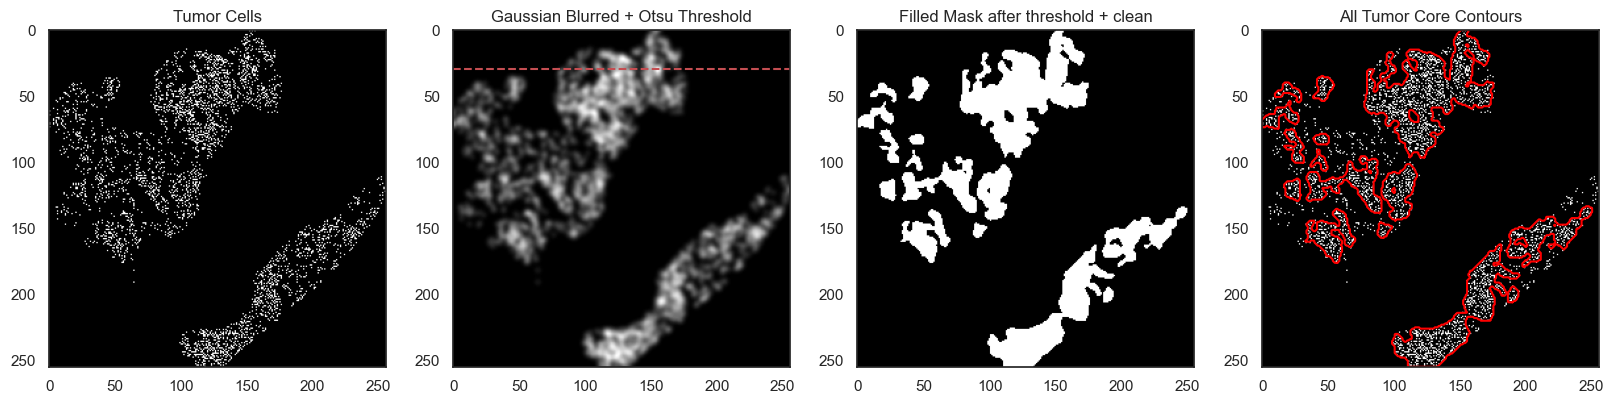

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.010016
B_cells                        0.002049
CD4+_T_cells                   0.002959
CD8+_T_cells                   0.018666
DCs                            0.000228
Endothelial_cells              0.019804
Granulocytes                   0.000455
Lymphatic_endothelial_cells    0.030731
M1_M2_macrophages              0.017756
M1_macrophages                 0.007512
M2_macrophages                 0.043023
MDSCs                          0.003415
Mast_cells                     0.000455
NFC                            0.179832
NK_cells                       0.006601
Plasma_cells                   0.000455
Treg_T_cells                   0.004325
Tumor_cells                    0.651719
dtype: float64
Processing experiment: Run141_ROI4


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



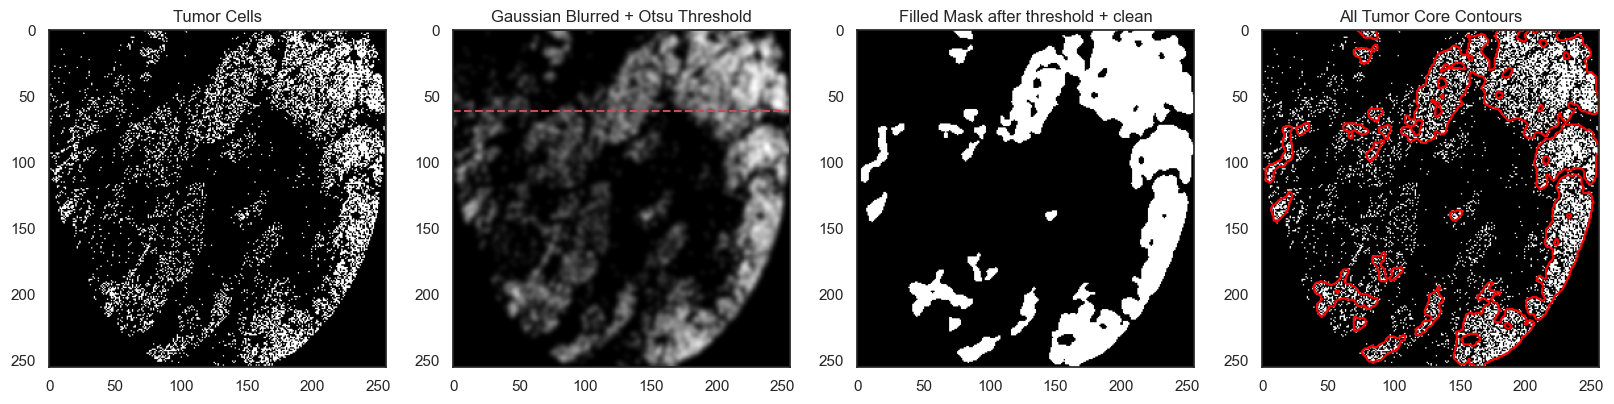

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.042322
B_cells                        0.001507
CD4+_T_cells                   0.009646
CD8+_T_cells                   0.016097
DCs                            0.001809
Endothelial_cells              0.005727
Granulocytes                   0.094894
Lymphatic_endothelial_cells    0.002170
M1_M2_macrophages              0.004461
M1_macrophages                 0.003075
M2_macrophages                 0.038826
MDSCs                          0.119612
Mast_cells                     0.000121
NFC                            0.083379
NK_cells                       0.000362
Plasma_cells                   0.000844
Treg_T_cells                   0.003678
Tumor_cells                    0.571472
dtype: float64
Processing experiment: Run141_ROI23


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



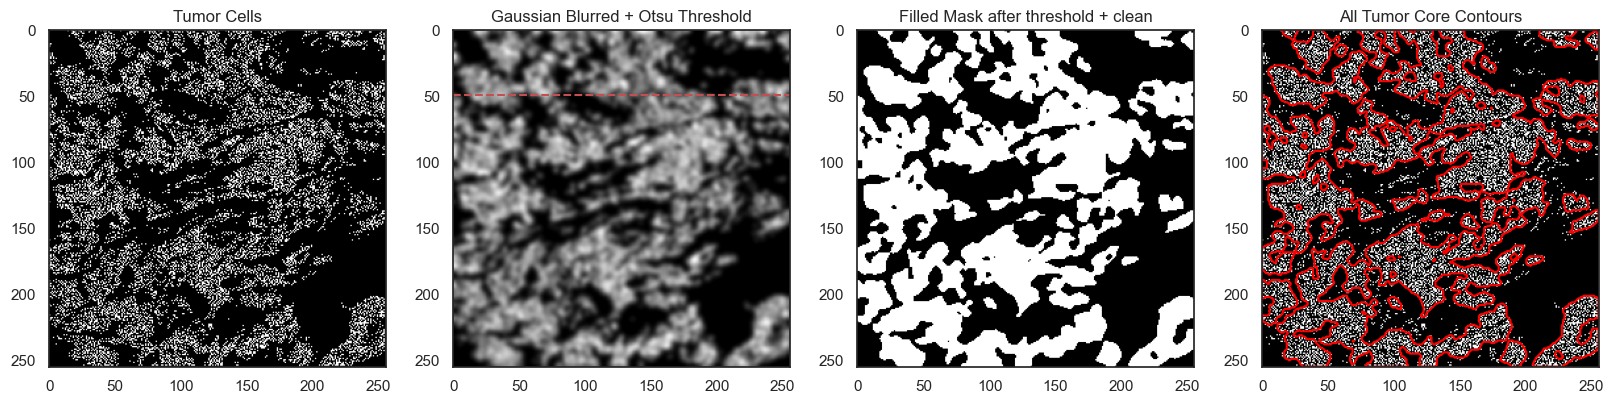

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.030920
B_cells                        0.000084
CD4+_T_cells                   0.001690
CD8+_T_cells                   0.000676
DCs                            0.003210
Endothelial_cells              0.005829
Granulocytes                   0.001352
Lymphatic_endothelial_cells    0.000000
M1_M2_macrophages              0.007350
M1_macrophages                 0.000507
M2_macrophages                 0.005491
Mast_cells                     0.000422
NK_cells                       0.000253
Treg_T_cells                   0.000253
Tumor_cells                    0.941962
dtype: float64
Processing experiment: Run141_ROI3


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



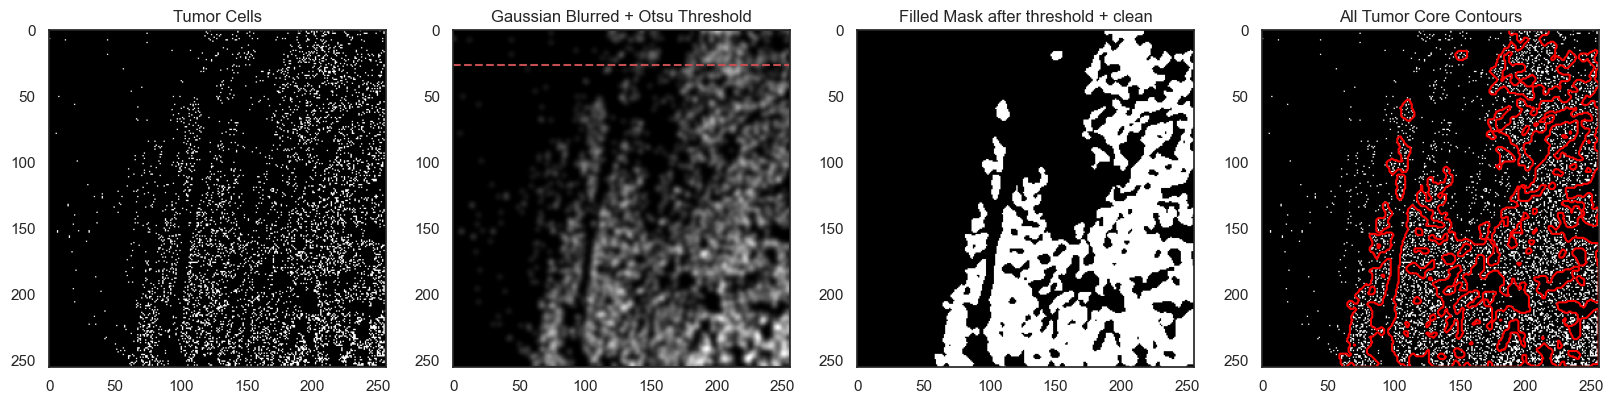

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.009820
B_cells                        0.000258
CD4+_T_cells                   0.001421
CD8+_T_cells                   0.000258
DCs                            0.001163
Endothelial_cells              0.002455
Granulocytes                   0.211138
Lymphatic_endothelial_cells    0.000258
M1_M2_macrophages              0.002326
M1_macrophages                 0.001809
M2_macrophages                 0.019253
MDSCs                          0.118362
Mast_cells                     0.000129
NFC                            0.014989
NK_cells                       0.000129
Plasma_cells                   0.001421
Treg_T_cells                   0.001292
Tumor_cells                    0.613516
dtype: float64
Processing experiment: Run145_ROI9


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



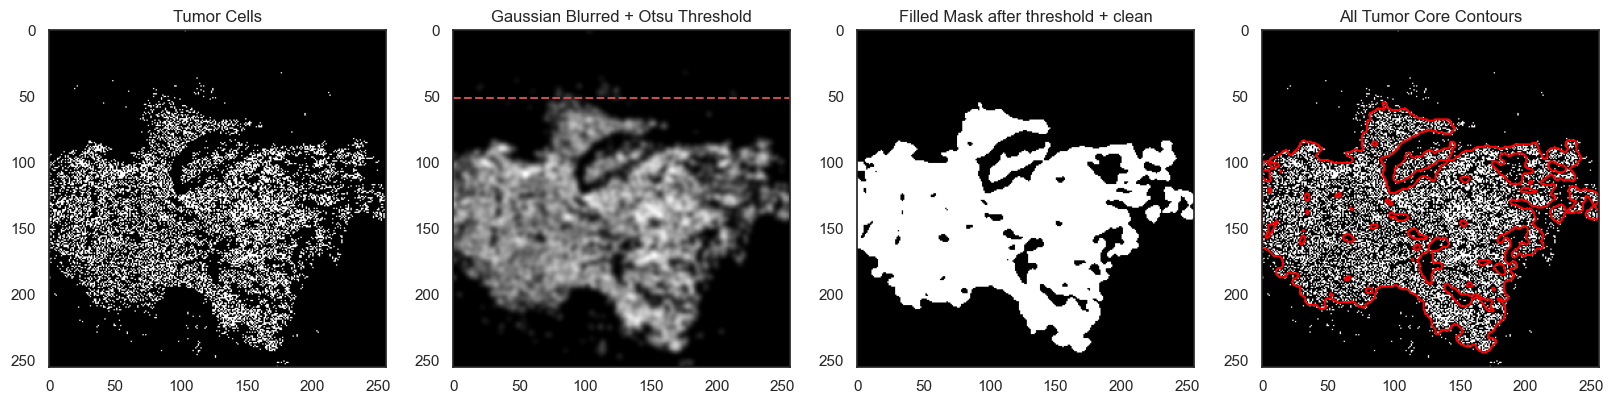

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.001911
CD4+_T_cells                   0.011137
CD8+_T_cells                   0.030974
DCs                            0.000857
Endothelial_cells              0.028338
Granulocytes                   0.073283
Lymphatic_endothelial_cells    0.000461
M1_M2_macrophages              0.000000
M1_macrophages                 0.000593
M2_macrophages                 0.003954
MDSCs                          0.038223
Mast_cells                     0.000593
NFC                            0.138131
NK_cells                       0.000000
Plasma_cells                   0.000000
Treg_T_cells                   0.001582
Tumor_cells                    0.669962
dtype: float64
Processing experiment: Run141_ROI14


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



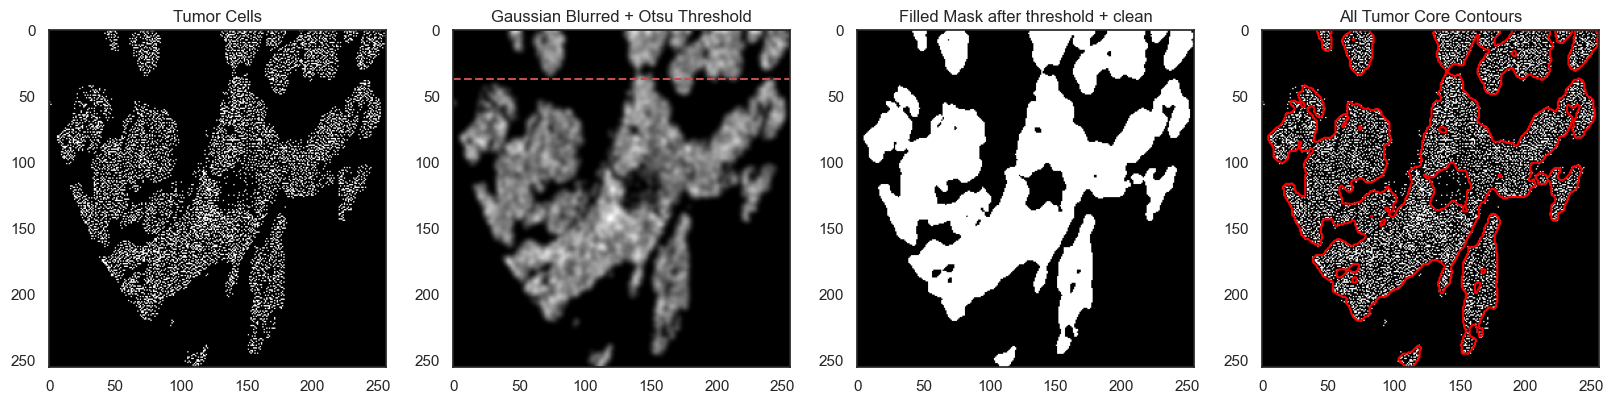

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.013178
B_cells                        0.010517
CD4+_T_cells                   0.000253
CD8+_T_cells                   0.000507
DCs                            0.000000
Endothelial_cells              0.001647
Granulocytes                   0.000253
Lymphatic_endothelial_cells    0.000760
M1_M2_macrophages              0.002281
M1_macrophages                 0.004942
M2_macrophages                 0.013305
MDSCs                          0.004815
Mast_cells                     0.000000
NFC                            0.003675
NK_cells                       0.000634
Plasma_cells                   0.000634
Treg_T_cells                   0.000000
Tumor_cells                    0.942600
dtype: float64
Processing experiment: Run145_ROI14


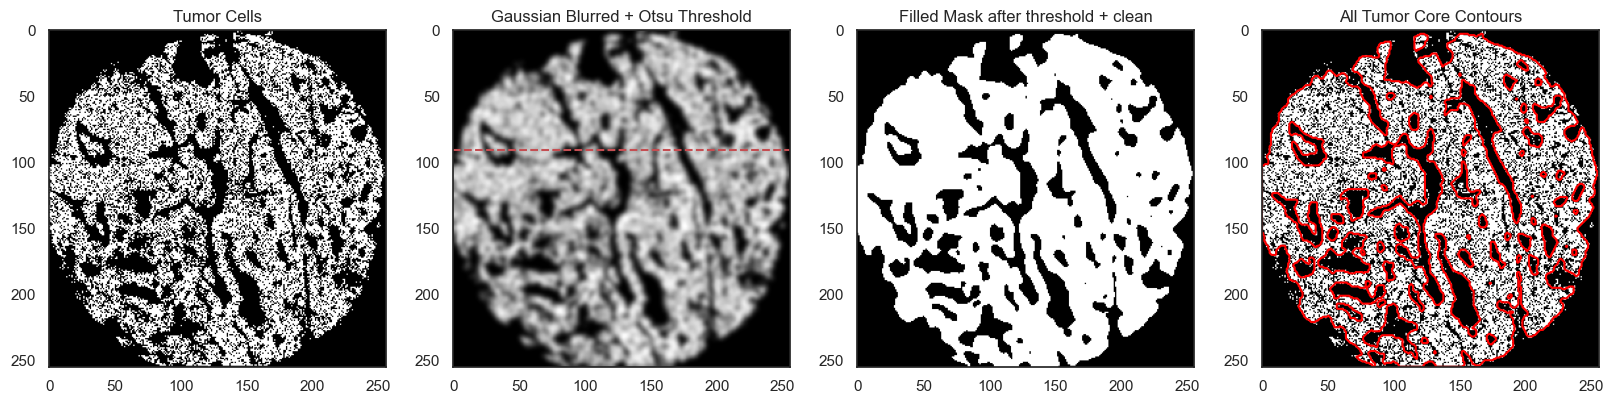

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.005530
B_cells                        0.002360
CD4+_T_cells                   0.004136
CD8+_T_cells                   0.001956
DCs                            0.001663
Endothelial_cells              0.012993
Granulocytes                   0.001034
Lymphatic_endothelial_cells    0.050779
M1_M2_macrophages              0.002068
M1_macrophages                 0.000719
M2_macrophages                 0.048014
MDSCs                          0.015061
Mast_cells                     0.001978
NFC                            0.126958
NK_cells                       0.000135
Treg_T_cells                   0.002630
Tumor_cells                    0.721986
dtype: float64
Processing experiment: Run145_ROI13


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



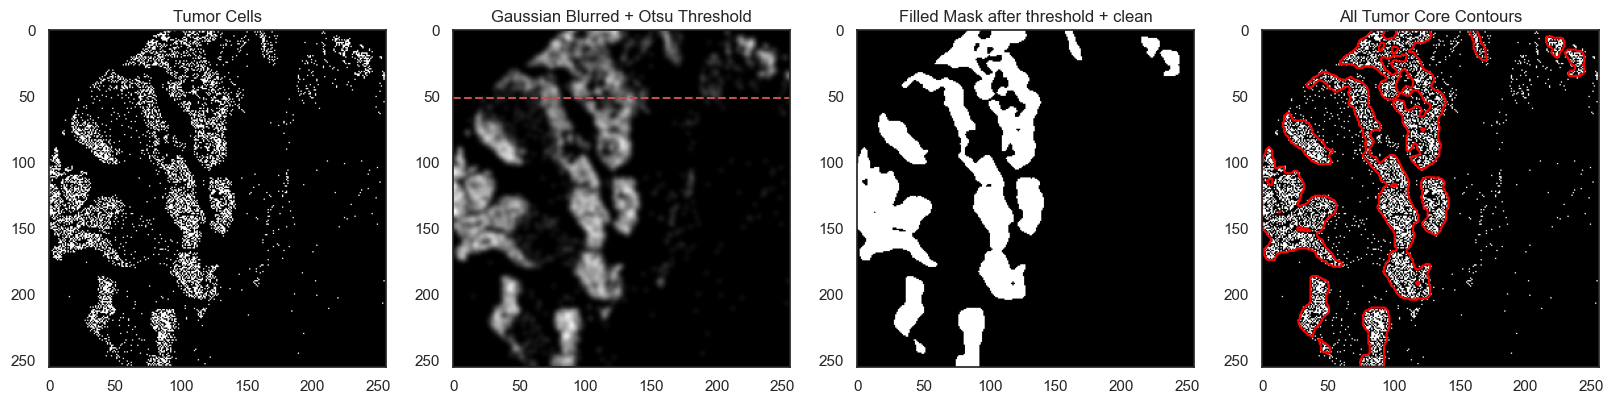

Cell type proportions inside tumor core:
cell_type
Actin+_cells                   0.011164
B_cells                        0.005505
CD4+_T_cells                   0.000765
CD8+_T_cells                   0.005964
DCs                            0.003212
Endothelial_cells              0.004282
Granulocytes                   0.001223
Lymphatic_endothelial_cells    0.012234
M1_M2_macrophages              0.011928
M1_macrophages                 0.001835
M2_macrophages                 0.035632
MDSCs                          0.053831
Mast_cells                     0.001529
NFC                            0.024010
NK_cells                       0.000000
Treg_T_cells                   0.001376
Tumor_cells                    0.825508
dtype: float64


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/400704780.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [13]:
adata.obs['distance_to_tumor'] = np.nan
adata.obs['n_cores'] = np.nan
adata.obs['median_diffusion_score'] = np.nan
proportions_df = {}
for exp in adata.obs['exp_name'].unique():
    print(f"Processing experiment: {exp}")
    # Subset adata for the current experiment
    adata_exp = adata[adata.obs['exp_name'] == exp]
    polygons, distances, n_cores, median_diffusion_score = extract_all_tumor_cores_otsu(adata_exp, plot=True)
    adata.obs.loc[adata_exp.obs.index, 'distance_to_tumor'] = distances
    adata.obs.loc[adata_exp.obs.index, 'n_cores'] = n_cores
    adata.obs.loc[adata_exp.obs.index, 'median_diffusion_score'] = median_diffusion_score
    #calculate proportions of cells that made it to the tumor 
    proportions = cell_type_proportions_in_tumor_cores(adata_exp, polygons)
    proportions_df[exp] = proportions

In [16]:
adata.obs["new_cell_type"] = adata.obs["cell_type"].astype(str)
#call tumor_cells that have distance_to_tumor 0 tumor core
adata.obs.loc[(adata.obs["cell_type"] == "Tumor_cells") & (adata.obs["distance_to_tumor"] == 0), "new_cell_type"] = "Tumor_core"

array(['NFC', 'Tumor_core', 'Actin+_cells', 'Tumor_cells', 'CD8+_T_cells',
       'M1_macrophages', 'Treg_T_cells', 'M2_macrophages', 'DCs',
       'Endothelial_cells', 'CD4+_T_cells', 'Mast_cells',
       'Lymphatic_endothelial_cells', 'Granulocytes', 'M1_M2_macrophages',
       'Plasma_cells', 'B_cells', 'MDSCs', 'Epithelial_cells', 'NK_cells'],
      dtype=object)

## How interactions are similar across all sampless

## Spatial Interaction

In [17]:
sm.tl.spatial_interaction (adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="new_cell_type",
                         method='delaunay',
                         permutation=300,
                         imageid='exp_name',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['Run141_ROI11']
Categories (1, object): ['Run141_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI16']
Categories (1, object): ['Run141_ROI16']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI7']
Categories (1, object): ['Run141_ROI7']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI3']
Categories (1, object): ['Run145_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run1

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run145_ROI11']
Categories (1, object): ['Run145_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI15']
Categories (1, object): ['Run141_ROI15']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI1']
Categories (1, object): ['Run145_ROI1']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI4']
Categories (1, object): ['Run141_ROI4']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


...

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run145_ROI13']
Categories (1, object): ['Run145_ROI13']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results


AnnData object with n_obs × n_vars = 492873 × 65
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [93]:
heatmap_data = adata.uns['scimap_delaunay_conditional_zscore']
heatmap_data.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
heatmap_data.columns = heatmap_data.columns.str.replace('zscore_', '')  # remove zscore_ from column names
ordered_columns = adata.obs.sort_values(by = "patient_ID").loc[:,["exp_name", "patient_ID", "patient_exp"]].drop_duplicates().reset_index(drop=True)
heatmap_data = heatmap_data[ordered_columns["exp_name"]]
heatmap_data.columns = ordered_columns["patient_exp"].values
#remove any index that has Tumor_cells or epithelial cells
heatmap_data = heatmap_data[~heatmap_data.index.str.contains("-Tumor_core")]
#only keep index that has Tumor-core-
heatmap_data = heatmap_data[heatmap_data.index.str.contains("Tumor_core-")]
#make data in long format
heatmap_data_long = heatmap_data.reset_index().melt(id_vars='index', var_name='patient_exp', value_name='zscore')
# rename index as cell type and column zscore as median_distance
heatmap_data_long.rename(columns={'index': 'cell_type',
                                  'zscore':'median_distance'}, inplace=True)
#make second column the first column
heatmap_data_long = heatmap_data_long[['patient_exp', 'cell_type', 'median_distance']]
heatmap_data_long['cell_type'] = heatmap_data_long['cell_type'].str.replace('Tumor_core-', '', regex=False)

In [94]:
#calculate the total number of each cell type per patient_exp
heatmap_data_long["total_cells"] = adata.obs.groupby(["patient_exp", "cell_type"])["distance_to_tumor"].count().values
#make distance_to_tumor NA for any row with less than 10 total_cells
heatmap_data_long.loc[heatmap_data_long["total_cells"] < 50, "distance_to_tumor"] = np.nan
heatmap_data_long = heatmap_data_long[~heatmap_data_long["cell_type"].isin(["Tumor_cells"])]
heatmap_data_long = heatmap_data_long.drop(columns=["total_cells", "distance_to_tumor"])
#make the values that are -Inf or Inf na
heatmap_data_long['median_distance'] = heatmap_data_long['median_distance'].replace([np.inf, -np.inf], np.nan)
heatmap_data_long.to_csv('/Users/jawadalaaedeen/Desktop/median_distance_to_tumor_2.csv', index=False)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/2829683071.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [103]:
median_distance = adata.obs.groupby(["patient_exp", "cell_type"])["distance_to_tumor"].median().reset_index()
#calculate the total number of each cell type per patient_exp
median_distance["total_cells"] = adata.obs.groupby(["patient_exp", "cell_type"])["distance_to_tumor"].count().values
#make distance_to_tumor NA for any row with less than 10 total_cells
median_distance.loc[median_distance["total_cells"] < 15, "distance_to_tumor"] = np.nan
#drop the total_cells column
median_distance = median_distance.drop(columns=["total_cells"])
median_distance = median_distance.rename(columns={"distance_to_tumor": "median_distance"})
median_distance = median_distance[~median_distance["cell_type"].isin(["Tumor_cells"])]  # Exclude tumor cells and NFC
median_distance.to_csv('/Users/jawadalaaedeen/Desktop/median_distance_to_tumor.csv', index=False)
# median_distance = median_distance.pivot(index="cell_type", columns="exp_name", values="median_distance")
# #Heatmap
# fig = plt.figure(figsize=(10, 8))
# sns.heatmap(median_distance, cmap="viridis", annot=True, fmt=".2f", cbar_kws={'label': 'Median Distance to Tumor (px)'})
# plt.title("Median Distance to Tumor by Cell Type and Experiment")
# plt.xlabel("Experiment")
# plt.ylabel("Cell Type")
# plt.tight_layout()


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/459620125.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4600/459620125.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [97]:
adata.obs.median_diffusion_score.unique()

array([1.8759221 , 1.35888581, 1.35577071, 1.84787158, 1.46035688,
       1.78194606, 1.67935381, 1.33258689, 1.89677286, 1.49131235,
       1.29051357, 1.86656888, 1.55569517, 1.33647667, 1.51059543,
       1.29901093, 1.57403071, 1.27423308, 1.75765495])

In [24]:
adata.obs.loc[:, ["outcome_group", "exp_name", "site"]].drop_duplicates()

,outcome_group,exp_name,site
0,long_term survival,Run141_ROI11,extrahepatic bile ducts
0-1,short_term survival,Run141_ROI16,lung
0-2,short_term survival,Run141_ROI7,lung
0-3,long_term survival,Run141_ROI19,"cervical, A. carotis int. right"
0-4,short_term survival,Run141_ROI1,lung hilus right
0-5,long_term survival,Run141_ROI8,extrahepatic bile ducts
0-6,long_term survival,Run141_ROI17,"cervical, A. carotis int. right"
0-7,short_term survival,Run141_ROI15,"sample: metastasis left tigh, skin \nprimary s..."
0-8,short_term survival,Run141_ROI4,central left lung
0-9,short_term survival,Run141_ROI23,"intrathoracic, right bronchus"


In [12]:
cell_colors = {
    "Tumor_cells": "#FF6347",  # Tomato red
    "Actin+_cells": "grey",  # Steel blue
    "CD8+_T_cells": "#32CD32",  # Lime green
    "M1_macrophages": "#FFD700",  # Gold
    "Treg_T_cells": "#8A2BE2",  # Blue violet
    "M2_macrophages": "#00FA9A",  # Medium spring green
    "DCs": "#FF4500",  # Orange red
    "Endothelial_cells": "#2E8B57",  # Sea green
    "CD4+_T_cells": "#9932CC",  # Dark orchid
    "Mast_cells": "#DAA520",  # Goldenrod
    "Lymphatic_endothelial_cells": "#A52A2A",  # Brown
    "Granulocytes": "#C71585",  # Medium violet red
    "M1_M2_macrophages": "#D2691E",  # Chocolate
    "Plasma_cells": "#8B0000",  # Dark red
    "B_cells": "#4169E1",  # Royal blue
    "MDSCs": "#B22222",  # Firebrick
    "Epithelial_cells": "#228B22",  # Forest green
    "NK_cells": "#FF1493"  # Deep pink
}

In [119]:
long_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"]]
short_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"]]


In [121]:
boxplot_data = heatmap_data.melt(var_name='variable', value_name='value', ignore_index=False)
boxplot_data = boxplot_data.filter(like = "CD8+_T_cells-Tumor_cells", axis=0)
boxplot_data["group"] = np.where(boxplot_data["variable"].isin(long_term_zscore), "Long_term", "Short_term")
boxplot_data


,variable,value,group
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI11,-15.521816,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI19,-8.852351,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI8,-28.027726,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI17,-14.573462,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI16,0.350344,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI7,1.055972,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI15,1.813534,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI23,1.628872,Short_term


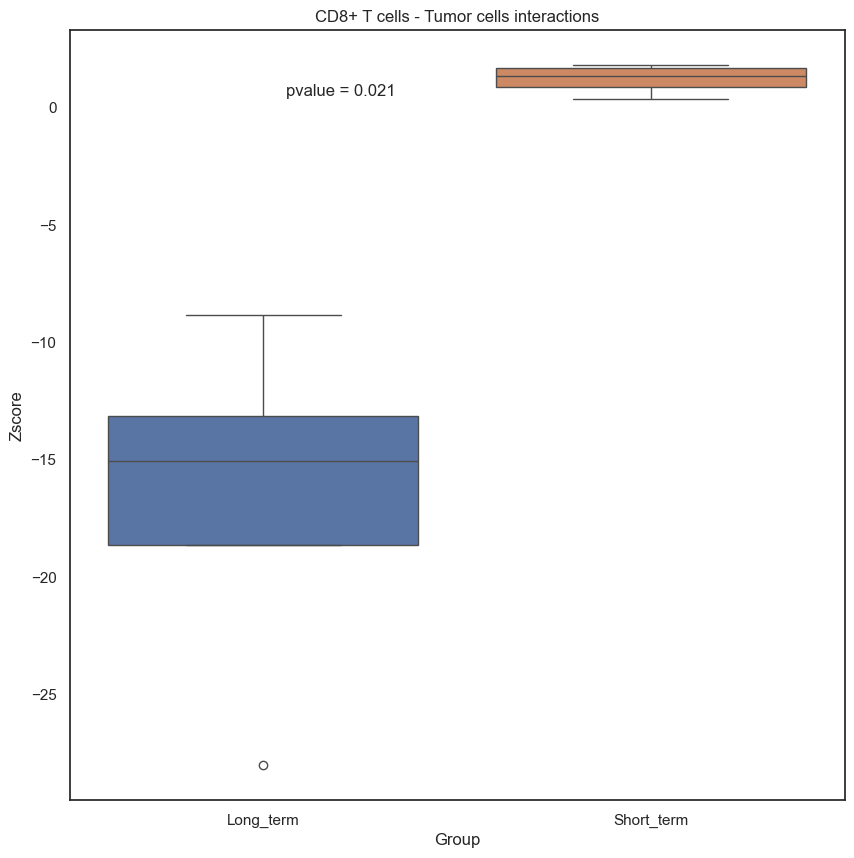

In [136]:
#build a boxplot based on boxplt_data based on matplot
#add the jitter to the boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x='group', y='value', hue='group', data=boxplot_data)
#add title to box plot and labels
plt.title('CD8+ T cells - Tumor cells interactions')
plt.xlabel('Group')
plt.ylabel('Zscore')
#calculate pvalue based on wilcox and add it to the plot
pvalue = sp.stats.ranksums(boxplot_data[boxplot_data["group"] == "Long_term"]["value"], boxplot_data[boxplot_data["group"] == "Short_term"]["value"]).pvalue.round(3)
plt.text(0.2, 0.5, "pvalue = " + str(pvalue), fontsize=12, ha='center')
plt.show()

In [147]:
adata_long = adata[adata.obs["exp_name"].isin(["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"])]
adata_short = adata[adata.obs["exp_name"].isin(["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"])]

In [153]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


In [33]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                         phenotype='cell_type', label='2D_distance', imageid="exp_name")

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run145_ROI3
Processing Image: Run141_ROI19
Processing Image: Run141_ROI1
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run145_ROI10
Processing Image: Run145_ROI17
Processing Image: Run145_ROI11
Processing Image: Run103_ROI5
Processing Image: Run141_ROI15
Processing Image: Run145_ROI1
Processing Image: Run141_ROI4
Processing Image: Run141_ROI23
Processing Image: Run141_ROI3
Processing Image: Run145_ROI9
Processing Image: Run141_ROI14
Processing Image: Run145_ROI14
Processing Image: Run145_ROI13
Processing Image: Run103_ROI6


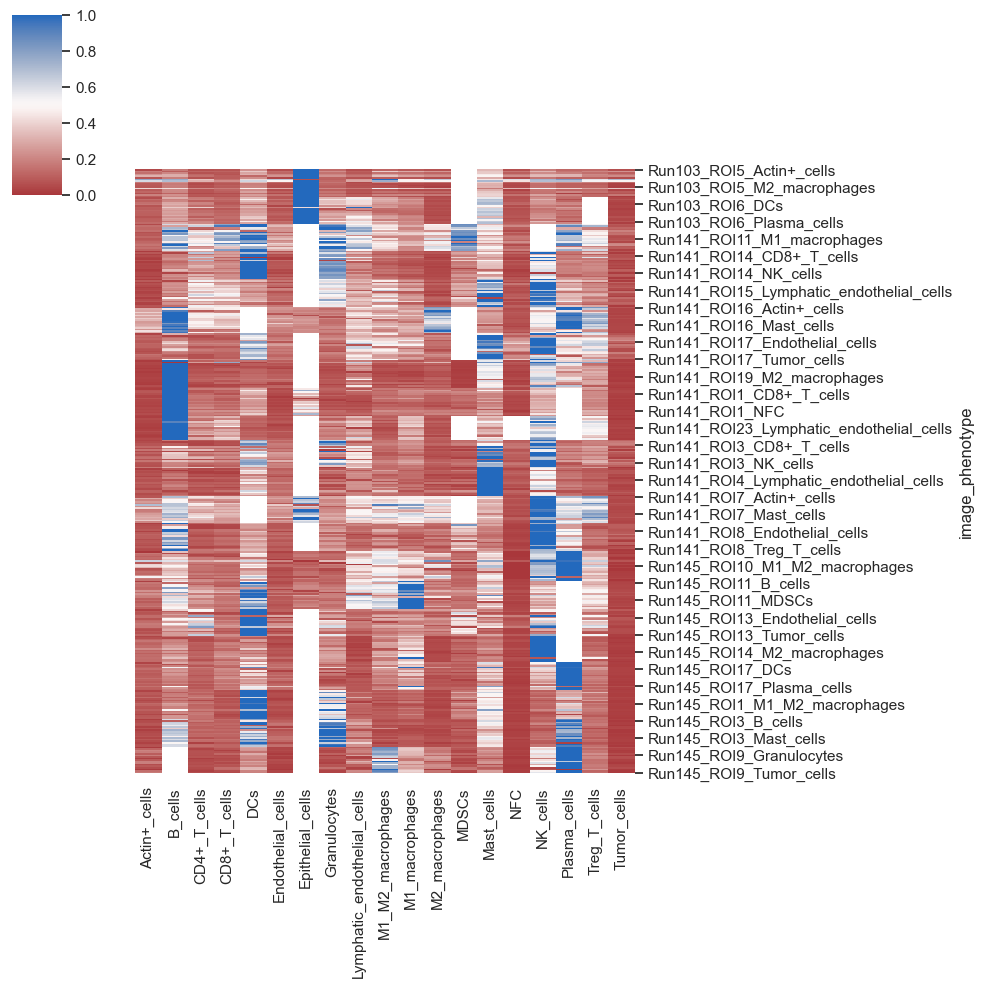

In [37]:
sm.pl.spatial_distance(adata, phenotype="cell_type", imageid="exp_name", spatial_distance='2D_distance', heatmap_summarize=False)

In [1]:
sm.pl.spatial_distance(adata_long, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')
sm.pl.spatial_distance(adata_short, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')


NameError: name 'sm' is not defined

In [9]:
#Proportion of Granulocytes to CD4+
proportion = adata.obs.groupby(["patient_ID", "cell_type"]).size().unstack().fillna(0)[["Granulocytes", "CD4+_T_cells", "CD8+_T_cells"]]
#calculate total number of cells
proportion["total"] = proportion.sum(axis=1)
proportion["T_cells"] = proportion["CD4+_T_cells"] + proportion["CD8+_T_cells"]
#calculate the proportion of Granulocytes to T_cells
proportion["Granulocytes_to_T_cells"] = proportion["Granulocytes"] / proportion["T_cells"]
#normalize it by the total number of cells
proportion["Granulocytes_to_T_cells"] = (proportion["Granulocytes_to_T_cells"] / proportion["total"]) * 1000
proportion = proportion.reset_index()
#stabalizze it
proportion["Granulocytes_to_T_cells"] = np.log1p(proportion["Granulocytes_to_T_cells"])
proportion

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_12917/183556760.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



cell_type,patient_ID,Granulocytes,CD4+_T_cells,CD8+_T_cells,total,T_cells,Granulocytes_to_T_cells
0,NMC_1,6,131,226,363,357,0.045260
1,NMC_2,704,155,176,1035,331,1.116768
2,NMC_4,1230,416,515,2161,931,0.477082
3,NMC_5,3183,1169,1472,5824,2641,0.188089
4,NMC_6,1737,1194,1877,4808,3071,0.111219
5,NMC_7,184,541,447,1172,988,0.147474
6,NMC_8,3008,182,144,3334,326,1.326424
7,NMC_9,5415,9492,8187,23094,17679,0.013176
8,NMC_13,9,28,25,62,53,1.318789
9,NMC_14,138,1623,596,2357,2219,0.026043


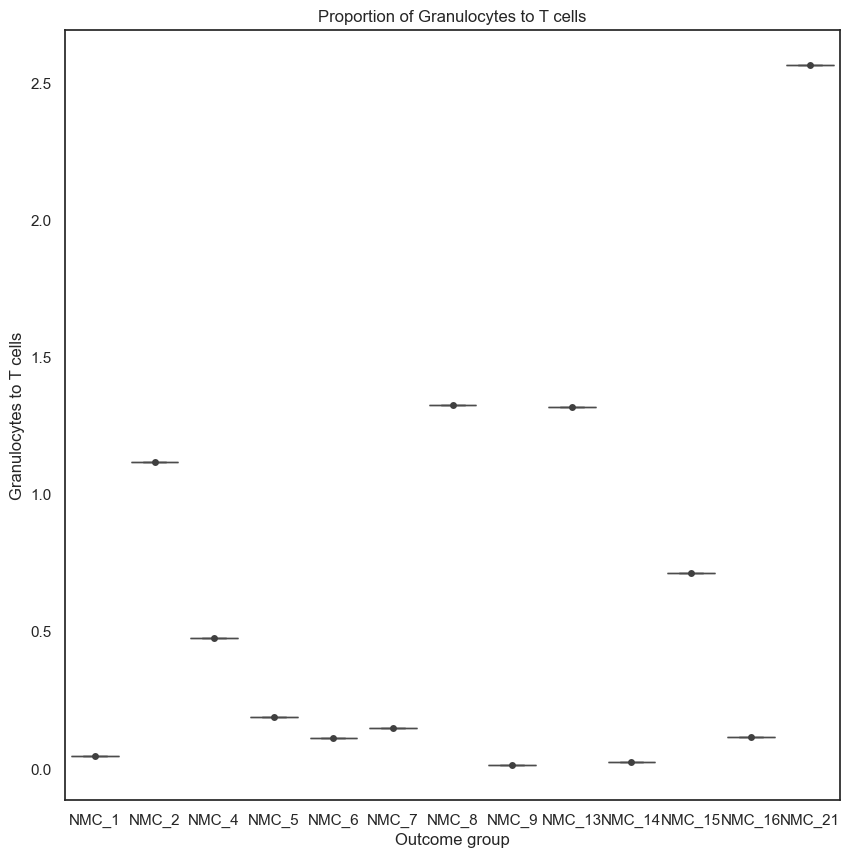

In [10]:
#plotting boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x="patient_ID", y="Granulocytes_to_T_cells", data=proportion)
sns.swarmplot(x="patient_ID", y="Granulocytes_to_T_cells", data=proportion, color=".25", dodge=True, legend=False, size=5)
plt.title("Proportion of Granulocytes to T cells")
plt.ylabel("Granulocytes to T cells")
plt.xlabel("Outcome group")
plt.show()

array([[ 3.364911  , -0.05504028,  1.4204489 , ..., -0.625759  ,
         0.6410527 ,  0.8886294 ],
       [ 0.24970348, -1.0339532 ,  1.7215923 , ...,  0.3054985 ,
         0.22106291,  0.9939115 ],
       [ 1.27325   , -1.2512585 ,  2.1407115 , ...,  0.30332476,
         0.21192957,  0.66310835],
       ...,
       [-0.99729556, -0.4536652 , -1.1325684 , ...,  0.93053603,
         0.14767537,  1.3336124 ],
       [-1.2233319 , -0.45298016, -1.4159251 , ...,  1.2389164 ,
         0.16221976,  1.4863019 ],
       [-1.1030433 , -0.42845234, -1.2105902 , ...,  0.426439  ,
        -0.08300974,  0.6062372 ]], dtype=float32)

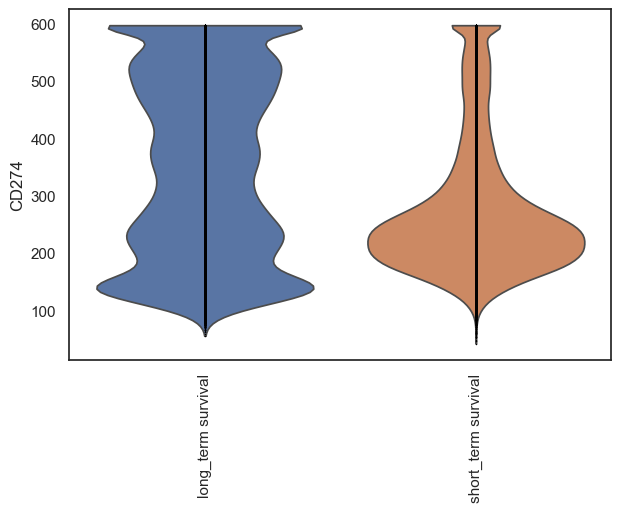

In [63]:
sc.pl.violin(adata, keys="CD274", groupby='outcome_group', jitter=0.001, rotation=90, size=1)
#Calculate pvalues

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_2346/1166554079.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



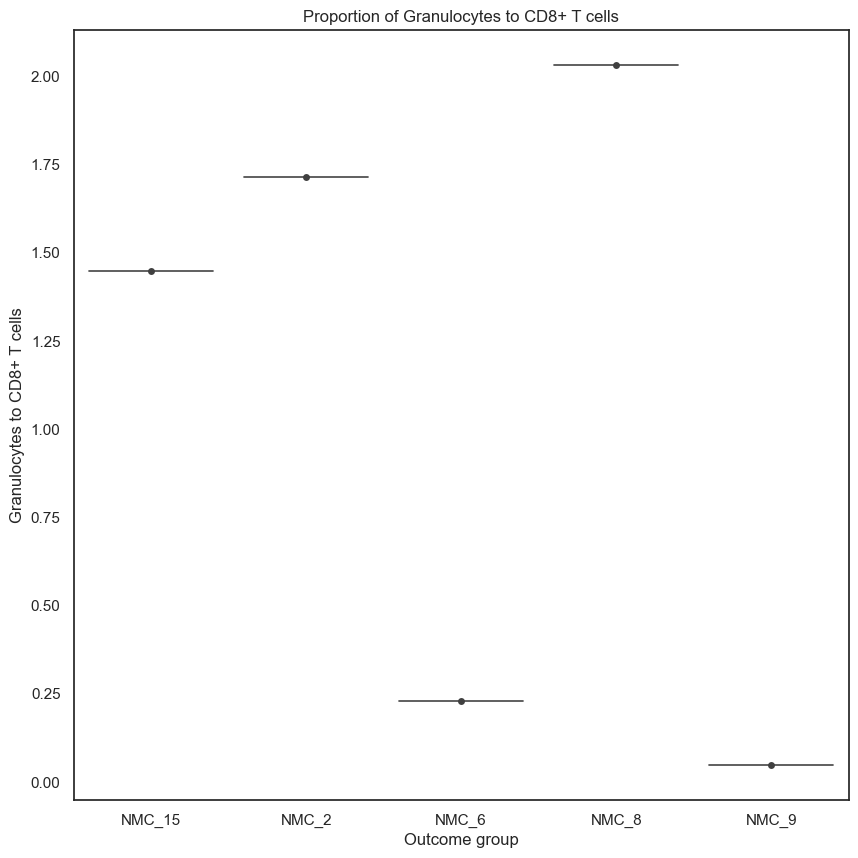

In [87]:
#ratio of Granulocytes to CD8+ T cells in adata_lung
proportion = adata_lung.obs.groupby(["patient_ID", "cell_type"]).size().unstack().fillna(0)[["Granulocytes", "CD8+_T_cells"]]
#calculate total number of cells
proportion["total"] = proportion.sum(axis=1)
proportion["T_cells"] = proportion["CD8+_T_cells"]
#calculate the proportion of Granulocytes to T_cells
proportion["Granulocytes_to_T_cells"] = proportion["Granulocytes"] / proportion["T_cells"]
#normalize it by the total number of cells
proportion["Granulocytes_to_T_cells"] = (proportion["Granulocytes_to_T_cells"] / proportion["total"]) * 1000
proportion = proportion.reset_index()
#stabalizze it
proportion["Granulocytes_to_T_cells"] = np.log1p(proportion["Granulocytes_to_T_cells"])
proportion
#plotting boxplot
plt.figure(figsize=(10, 10))
sns.violinplot(x="patient_ID", y="Granulocytes_to_T_cells", data=proportion)
sns.swarmplot(x="patient_ID", y="Granulocytes_to_T_cells", data=proportion, color=".25", dodge=True, legend=False, size=5)
plt.title("Proportion of Granulocytes to CD8+ T cells")
plt.ylabel("Granulocytes to CD8+ T cells")
plt.xlabel("Outcome group")
plt.show()


In [10]:
for i in adata.obs.cell_type.unique():
    print(i)

NFC
Tumor_cells
Actin+_cells
CD8+_T_cells
M1_macrophages
Treg_T_cells
M2_macrophages
DCs
Endothelial_cells
CD4+_T_cells
Mast_cells
Lymphatic_endothelial_cells
Granulocytes
M1_M2_macrophages
Plasma_cells
B_cells
MDSCs
Epithelial_cells
NK_cells


In [12]:
#create a column with T cells grouped, Macrophages grouped, and Granulocytes and MDScs
adata.obs["cell_type_group"] = adata.obs["cell_type"].replace({
    "CD4+_T_cells": "T cells",
    "CD8+_T_cells": "T cells",
    "Treg_T_cells": "T cells",
    "NK_cells": "T cells",
    "M1_macrophages": "Macrophages",
    "M2_macrophages": "Macrophages",
    "M1_M2_macrophages": "Macrophages",
    "MDSCs": "Granulocytes and MDSCs",
    "Granulocytes": "Granulocytes and MDSCs",
    "Plasma_cells": "B cells",
    "B_cells": "B cells"
})

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5766/588520696.py:2: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5766/529893712.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Figure size 1000x1000 with 0 Axes>

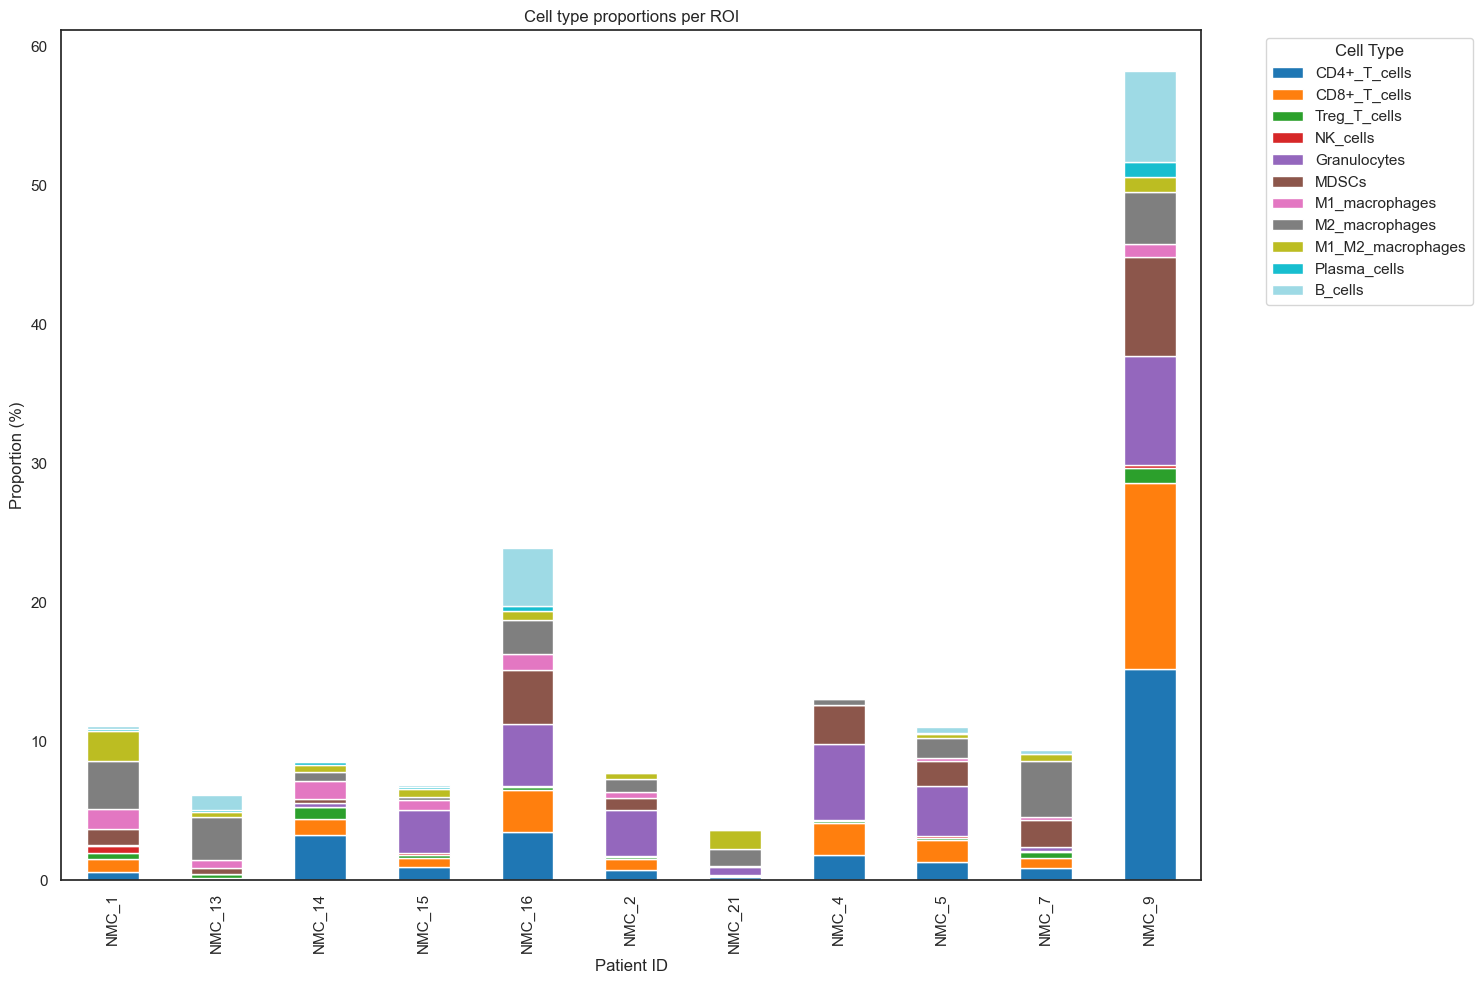

In [11]:
#calculate cell type proportions per ROI
counts_exp = adata.obs.groupby(["patient_ID", "cell_type"]).size().unstack()
counts_exp = counts_exp.div(counts_exp.sum(axis=1), axis=0).mul(100).round(2)
#select CD4+_T_cells, CD8+_T_cells, Granulocytes, Tumor_cells, MDSCs
counts_exp = counts_exp[["CD4+_T_cells", "CD8+_T_cells", "Treg_T_cells", "NK_cells", "Granulocytes", "MDSCs", "M1_macrophages", "M2_macrophages", "M1_M2_macrophages", "Plasma_cells", "B_cells"]]
#plot it as a stacked bar plot
plt.figure(figsize=(10, 10))
counts_exp.plot(kind='bar', stacked=True, colormap="tab20", figsize=(15, 10))
plt.title("Cell type proportions per ROI")
plt.xlabel("Patient ID")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=90)
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5766/3743139126.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Figure size 1000x1000 with 0 Axes>

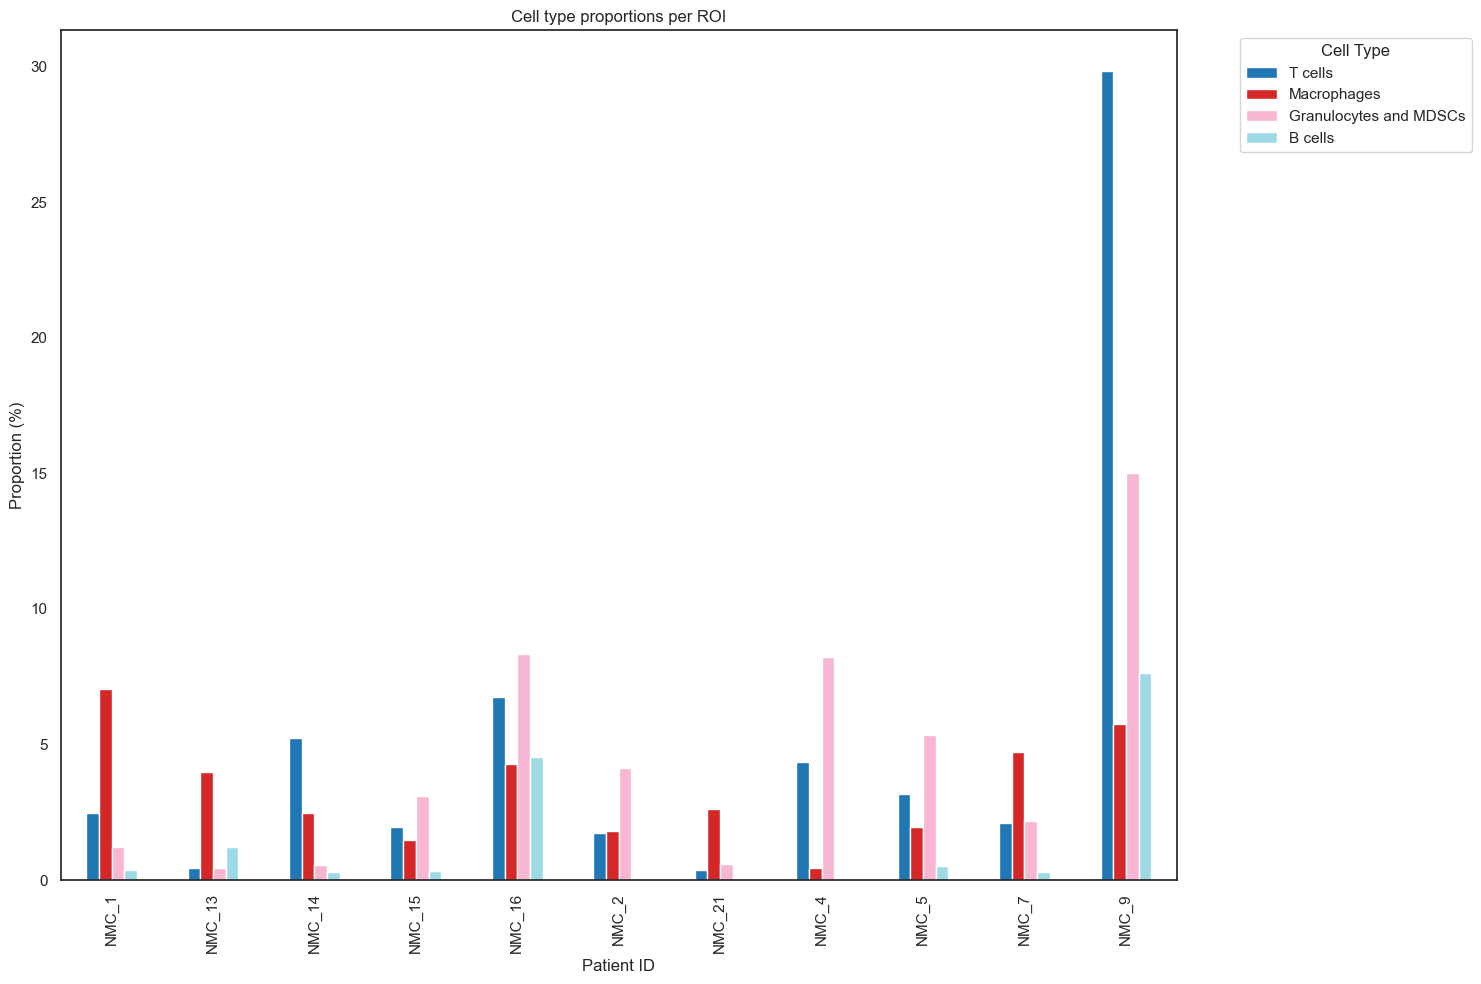

In [16]:
#calculate cell type proportions per ROI
counts_exp = adata.obs.groupby(["patient_ID", "cell_type_group"]).size().unstack()
counts_exp = counts_exp.div(counts_exp.sum(axis=1), axis=0).mul(100).round(2)
#select CD4+_T_cells, CD8+_T_cells, Granulocytes, Tumor_cells, MDSCs
counts_exp = counts_exp[["T cells", "Macrophages", "Granulocytes and MDSCs", "B cells"]]
#plot it as a stacked bar plot
plt.figure(figsize=(10, 10))
counts_exp.plot(kind='bar', stacked=False, colormap="tab20", figsize=(15, 10))
plt.title("Cell type proportions per ROI")
plt.xlabel("Patient ID")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=90)
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()